In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import joblib

from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid")

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("data/segmentation+data.csv", index_col=0)
df.head()

,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
ID,,,,,,,
100000001,0,0,67,2,124670,1,2
100000002,1,1,22,1,150773,1,2
100000003,0,0,49,1,89210,0,0
100000004,0,0,45,1,171565,1,1
100000005,0,0,53,1,149031,1,1


In [3]:
df.describe()

,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,0.457000,0.496500,35.909000,1.03800,120954.419000,0.810500,0.739000
std,0.498272,0.500113,11.719402,0.59978,38108.824679,0.638587,0.812533
min,0.000000,0.000000,18.000000,0.00000,35832.000000,0.000000,0.000000
25%,0.000000,0.000000,27.000000,1.00000,97663.250000,0.000000,0.000000
50%,0.000000,0.000000,33.000000,1.00000,115548.500000,1.000000,1.000000
75%,1.000000,1.000000,42.000000,1.00000,138072.250000,1.000000,1.000000
max,1.000000,1.000000,76.000000,3.00000,309364.000000,2.000000,2.000000


In [4]:
df.isnull().sum()

Sex                0
Marital status     0
Age                0
Education          0
Income             0
Occupation         0
Settlement size    0
dtype: int64

In [5]:
df_segmentation = df.copy()

In [6]:
### correlation estimate

df_segmentation.corr()

,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
Sex,1.000000,0.566511,-0.182885,0.244838,-0.195146,-0.202491,-0.300803
Marital status,0.566511,1.000000,-0.213178,0.374017,-0.073528,-0.029490,-0.097041
Age,-0.182885,-0.213178,1.000000,0.654605,0.340610,0.108388,0.119751
Education,0.244838,0.374017,0.654605,1.000000,0.233459,0.064524,0.034732
Income,-0.195146,-0.073528,0.340610,0.233459,1.000000,0.680357,0.490881
Occupation,-0.202491,-0.029490,0.108388,0.064524,0.680357,1.000000,0.571795
Settlement size,-0.300803,-0.097041,0.119751,0.034732,0.490881,0.571795,1.000000


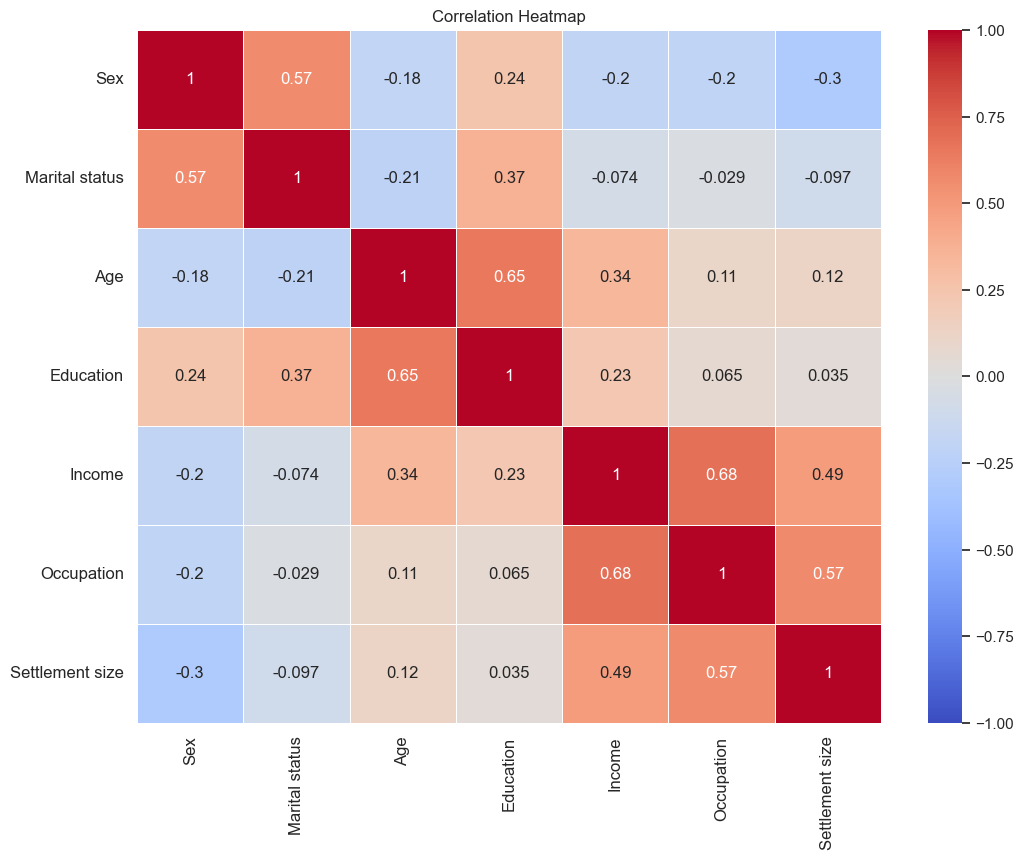

In [7]:
plt.figure(figsize=(12, 9))
s = sns.heatmap(df_segmentation.corr(),
                annot=True,
                cmap="coolwarm",
                linewidths=0.5,
                vmin = -1,
                vmax = 1)
s.set_xticklabels(s.get_xticklabels(), rotation=90, fontsize = 12)
s.set_yticklabels(s.get_yticklabels(), rotation=0, fontsize = 12)
plt.title("Correlation Heatmap")
plt.show()

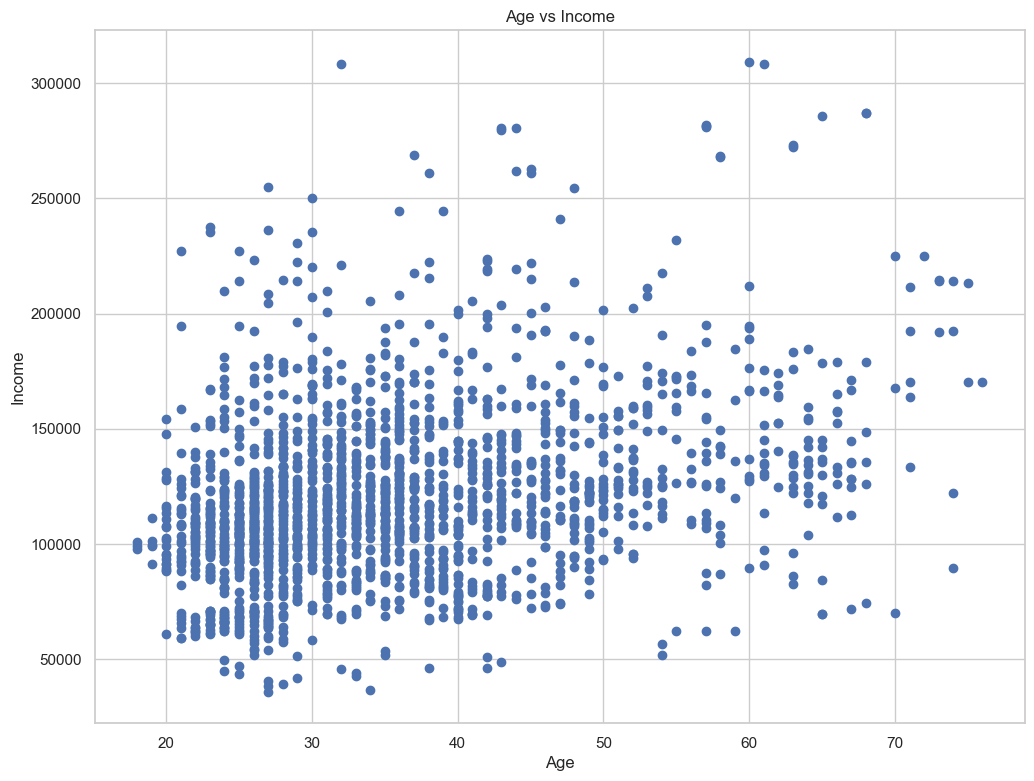

In [8]:
plt.figure(figsize=(12, 9))
plt.scatter(df_segmentation.iloc[:, 2], df_segmentation.iloc[:, 4])
plt.xlabel('Age')
plt.ylabel('Income')
plt.title('Age vs Income')
plt.show()

In [ ]:
# standardization
scaler = StandardScaler()
segmentation_std = scaler.fit_transform(df_segmentation)

In [10]:
## Hierarchical Clustering
hierarchical_clustering = linkage(segmentation_std, method='ward')

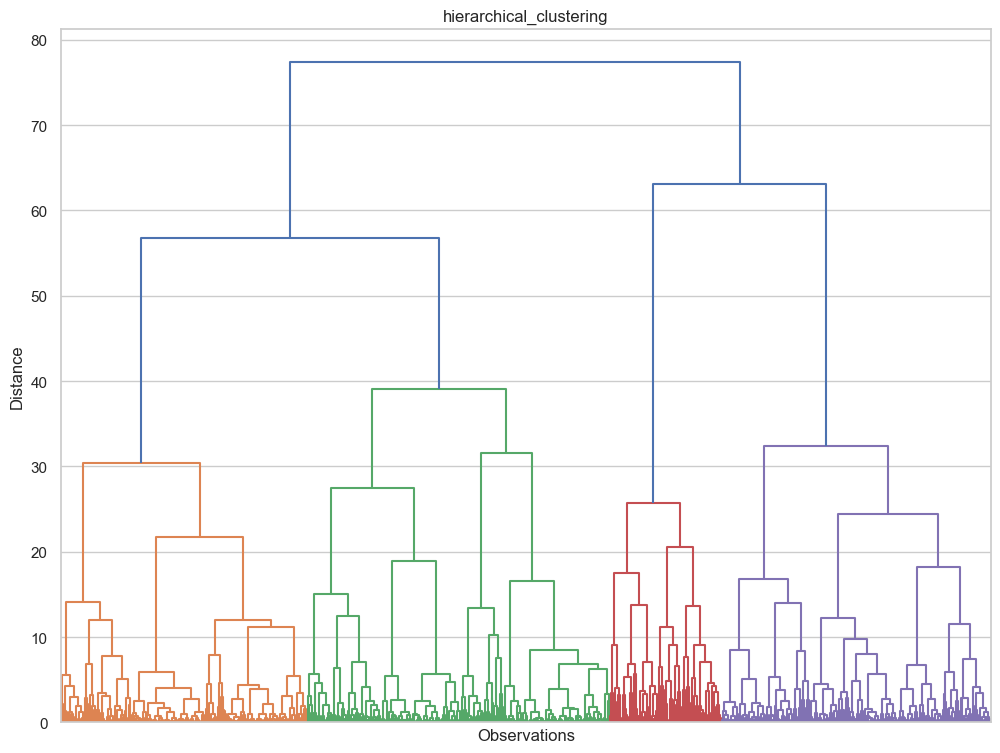

In [11]:
plt.figure(figsize=(12, 9))
plt.title("hierarchical_clustering")
plt.xlabel("Observations")
plt.ylabel("Distance")
dendrogram(hierarchical_clustering, leaf_rotation=90., leaf_font_size=8., no_labels=True, color_threshold=0.7*max(hierarchical_clustering[:, 2]))
plt.show()

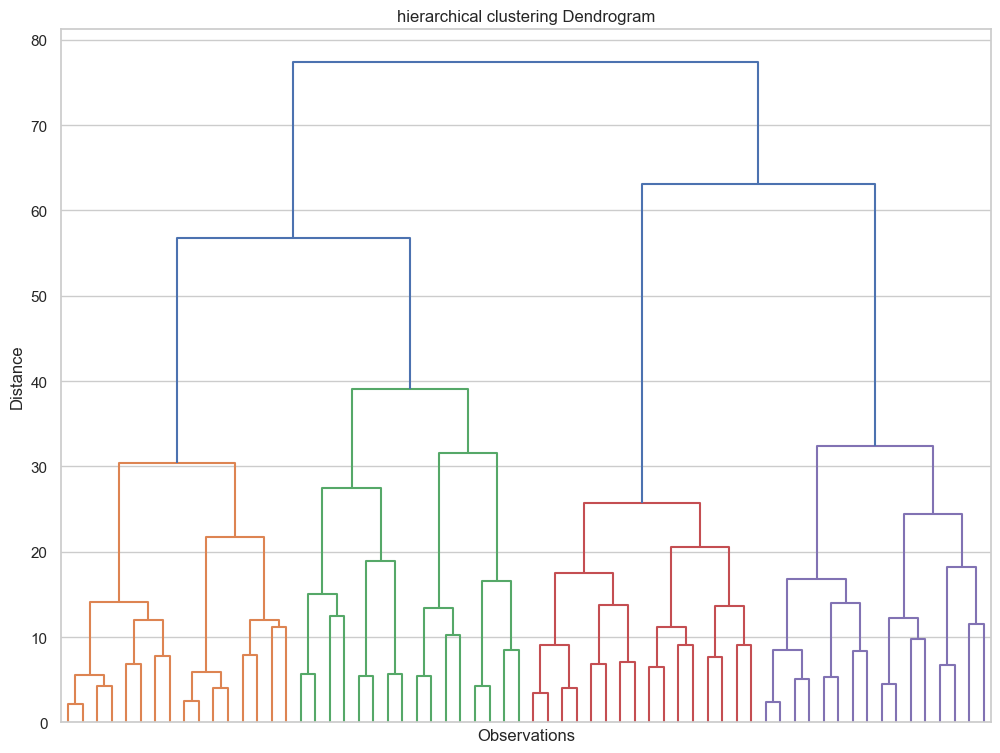

In [12]:
plt.figure(figsize = (12, 9))
plt.title("hierarchical clustering Dendrogram")
plt.xlabel("Observations")
plt.ylabel("Distance")
dendrogram(hierarchical_clustering,
           truncate_mode='level',
           p = 5,
           show_leaf_counts = False,
           no_labels = True)
plt.show()

In [13]:
### K-means Clustering
wscc = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(segmentation_std)
    wscc.append(kmeans.inertia_)

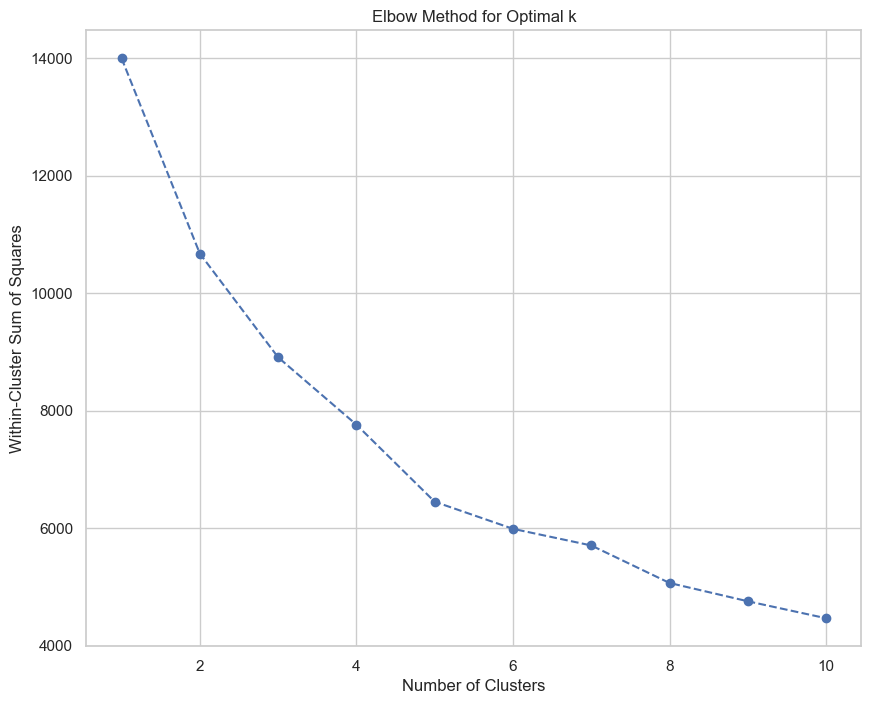

In [14]:
plt.figure(figsize=(10, 8))
plt.plot(range(1, 11), wscc, marker='o', linestyle='--')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters")
plt.ylabel("Within-Cluster Sum of Squares")
plt.show()

In [15]:
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
kmeans.fit(segmentation_std)

,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [16]:
df_segm_kmeans = df_segmentation.copy()

In [17]:
df_segm_kmeans['Segment K-means'] = kmeans.labels_

In [18]:
df_segm_analysis = df_segm_kmeans.groupby(['Segment K-means']).mean()
df_segm_analysis

,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
Segment K-means,,,,,,,
0,0.066543,0.000000,33.240296,0.489834,109932.785582,0.639556,0.611830
1,0.868254,0.785714,32.928571,1.163492,98466.955556,0.384127,0.006349
2,0.691099,0.979058,29.060209,1.104712,126838.926702,1.107330,1.324607
3,0.149888,0.277405,49.192394,1.467562,160958.722595,1.364653,1.425056


In [19]:
df_segm_analysis['N Obs'] = df_segm_kmeans[['Segment K-means', 'Sex']].groupby(['Segment K-means']).count()

In [20]:
df_segm_analysis['Prop Obs'] = df_segm_analysis['N Obs'] / df_segm_analysis['N Obs'].sum()

In [21]:
df_segm_analysis

,Sex,Marital status,Age,Education,Income,Occupation,Settlement size,N Obs,Prop Obs
Segment K-means,,,,,,,,,
0,0.066543,0.000000,33.240296,0.489834,109932.785582,0.639556,0.611830,541,0.2705
1,0.868254,0.785714,32.928571,1.163492,98466.955556,0.384127,0.006349,630,0.3150
2,0.691099,0.979058,29.060209,1.104712,126838.926702,1.107330,1.324607,382,0.1910
3,0.149888,0.277405,49.192394,1.467562,160958.722595,1.364653,1.425056,447,0.2235


In [22]:
df_segm_analysis.rename({0: 'standard', 1: 'fewer-opportunities', 2: 'career-focused', 3: 'well-off'}, inplace=True)

In [25]:
df_segm_analysis

,Sex,Marital status,Age,Education,Income,Occupation,Settlement size,N Obs,Prop Obs
Segment K-means,,,,,,,,,
standard,0.066543,0.000000,33.240296,0.489834,109932.785582,0.639556,0.611830,541,0.2705
fewer-opportunities,0.868254,0.785714,32.928571,1.163492,98466.955556,0.384127,0.006349,630,0.3150
career-focused,0.691099,0.979058,29.060209,1.104712,126838.926702,1.107330,1.324607,382,0.1910
well-off,0.149888,0.277405,49.192394,1.467562,160958.722595,1.364653,1.425056,447,0.2235


In [26]:
df_segm_kmeans['Labels'] = df_segm_kmeans['Segment K-means'].map({0: 'standard', 1: 'fewer-opportunities', 2: 'career-focused', 3: 'well-off'})

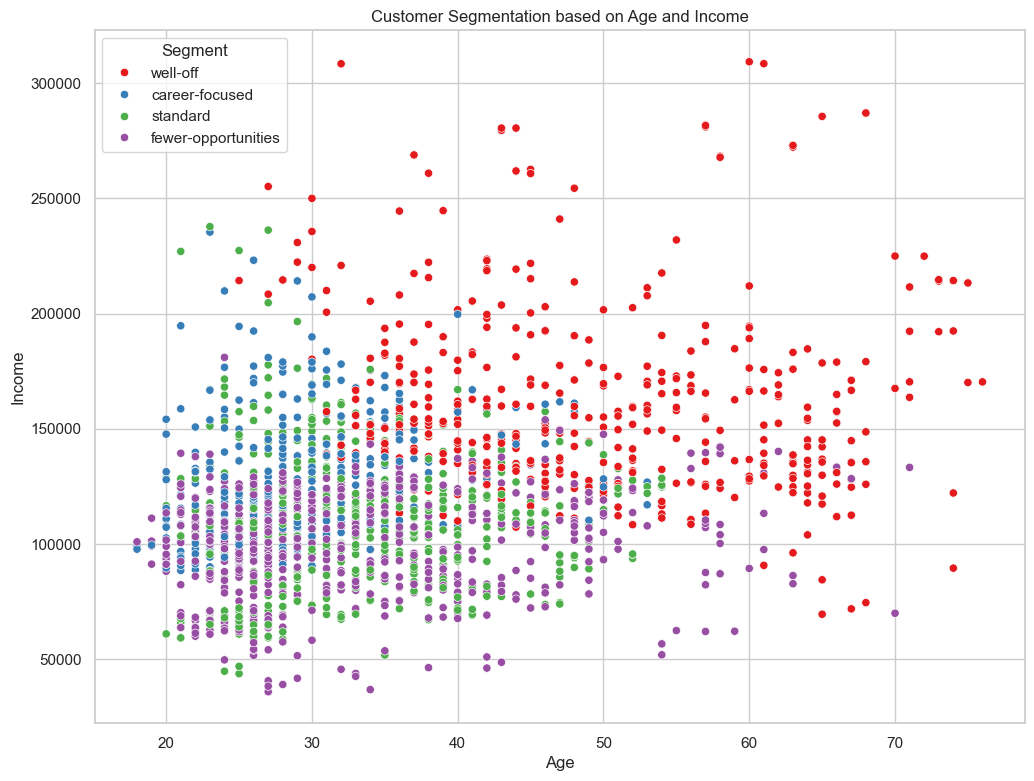

In [27]:
x_axis = df_segm_kmeans['Age']
y_axis = df_segm_kmeans['Income']
plt.figure(figsize=(12, 9))
sns.scatterplot(x=x_axis, y=y_axis, hue=df_segm_kmeans['Labels'], palette='Set1')
plt.title('Customer Segmentation based on Age and Income')
plt.xlabel('Age')
plt.ylabel('Income')
plt.legend(title='Segment')
plt.show()

In [30]:
### PCA
pca = PCA()

In [31]:
pca.fit(segmentation_std)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [32]:
pca.explained_variance_ratio_

array([0.35696328, 0.26250923, 0.18821114, 0.0755775 , 0.05716512,
       0.03954794, 0.02002579])

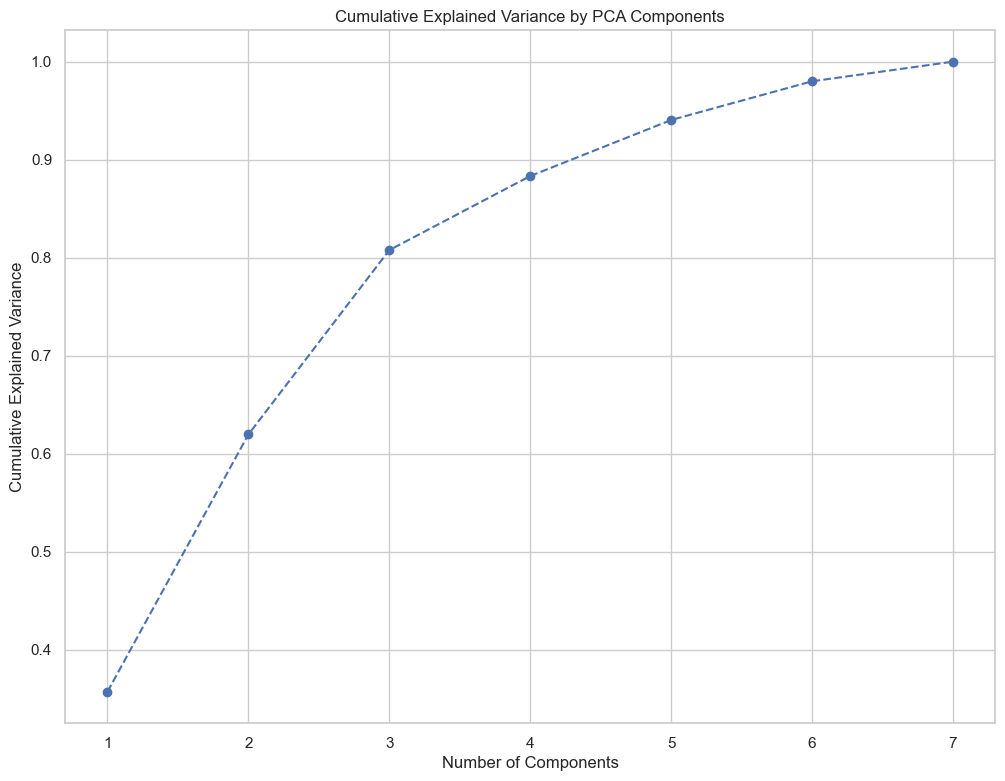

In [33]:
plt.figure(figsize=(12, 9))
plt.plot(range(1,8), pca.explained_variance_ratio_.cumsum(), marker = 'o', linestyle = '--')
plt.title("Cumulative Explained Variance by PCA Components")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.show()

In [34]:
pca = PCA(n_components=3)
pca.fit(segmentation_std)

,n_components,3
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [35]:
### PCA results
pca.components_

array([[-0.31469524, -0.19170439,  0.32609979,  0.15684089,  0.52452463,
         0.49205868,  0.46478852],
       [ 0.45800608,  0.51263492,  0.31220793,  0.63980683,  0.12468314,
         0.01465779, -0.06963165],
       [-0.29301261, -0.44197739,  0.60954372,  0.27560461, -0.16566231,
        -0.39550539, -0.29568503]])

In [36]:
df_pca_comp = pd.DataFrame(data = pca.components_,
                           columns = df_segmentation.columns.values,
                           index = ['Component 1', 'Component 2', 'Component 3'])
df_pca_comp

,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
Component 1,-0.314695,-0.191704,0.326100,0.156841,0.524525,0.492059,0.464789
Component 2,0.458006,0.512635,0.312208,0.639807,0.124683,0.014658,-0.069632
Component 3,-0.293013,-0.441977,0.609544,0.275605,-0.165662,-0.395505,-0.295685


([<matplotlib.axis.YTick at 0x117707100>,
 [Text(0, 0, 'Component 1'),
  Text(0, 1, 'Component 2'),
  Text(0, 2, 'Component 3')])

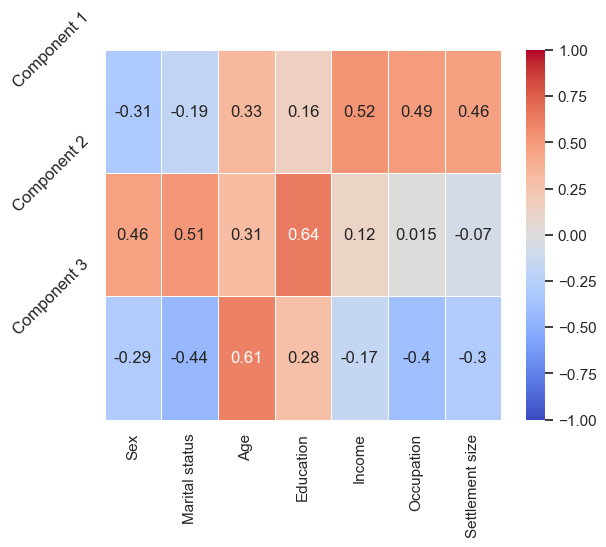

In [37]:
sns.heatmap(
    df_pca_comp,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    vmin=-1,
    vmax=1
)
plt.yticks([0, 1, 2],
           labels=['Component 1', 'Component 2', 'Component 3'],
           rotation=45,
           fontsize=12)

In [38]:
pca.transform(segmentation_std)

array([[ 2.51474593,  0.83412239,  2.1748059 ],
       [ 0.34493528,  0.59814564, -2.21160279],
       [-0.65106267, -0.68009318,  2.2804186 ],
       ...,
       [-1.45229829, -2.23593665,  0.89657125],
       [-2.24145254,  0.62710847, -0.53045631],
       [-1.86688505, -2.45467234,  0.66262172]], shape=(2000, 3))

In [39]:
scores_pca = pca.transform(segmentation_std)

In [40]:
###  K-means with PCA components
wscc_pca = []
for i in range(1, 11):
    kmeans_pca = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans_pca.fit(scores_pca)
    wscc_pca.append(kmeans_pca.inertia_)

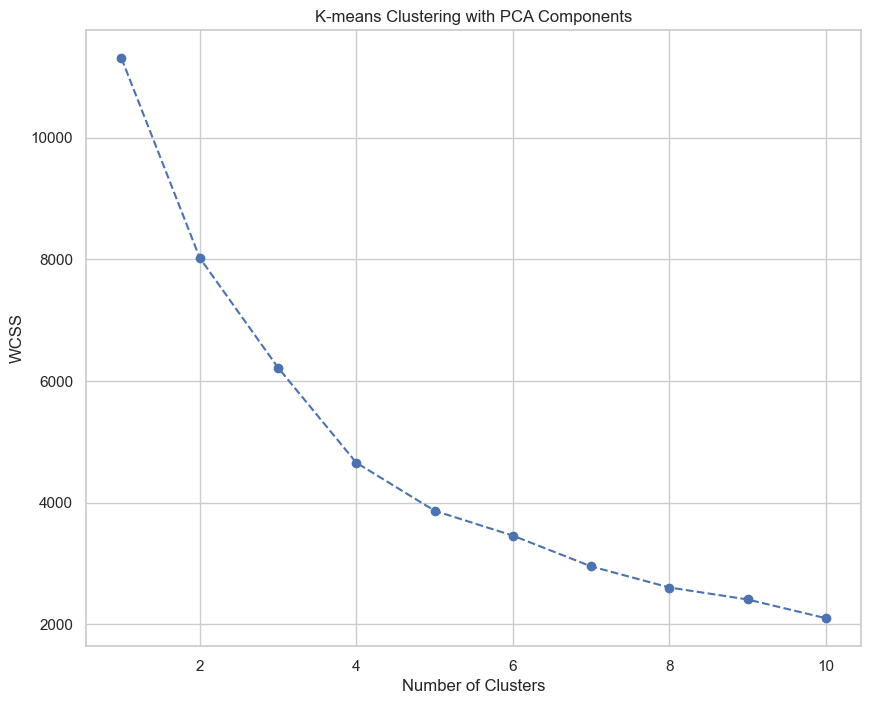

In [42]:
plt.figure(figsize=(10, 8))
plt.plot(range(1, 11), wscc_pca, marker = 'o', linestyle = '--')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('K-means Clustering with PCA Components')
plt.show()

In [43]:
kmeans_pca = KMeans(n_clusters=4, init='k-means++', random_state=42)

In [44]:
kmeans_pca.fit(scores_pca)

,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [45]:
### K-means clustering with PCA components
df_segm_pca_kmeans = pd.concat([df_segmentation.reset_index(drop = True), pd.DataFrame(scores_pca)], axis=1)
df_segm_pca_kmeans.columns.values[-3: ] = ['Component 1', 'Component 2', 'Component 3']
df_segm_pca_kmeans['Segment K-means PCA'] = kmeans_pca.labels_
df_segm_pca_kmeans.head()


,Sex,Marital status,Age,Education,Income,Occupation,Settlement size,Component 1,Component 2,Component 3,Segment K-means PCA
0,0,0,67,2,124670,1,2,2.514746,0.834122,2.174806,3
1,1,1,22,1,150773,1,2,0.344935,0.598146,-2.211603,2
2,0,0,49,1,89210,0,0,-0.651063,-0.680093,2.280419,1
3,0,0,45,1,171565,1,1,1.714316,-0.579927,0.730731,0
4,0,0,53,1,149031,1,1,1.626745,-0.440496,1.244909,0


In [46]:
df_segm_pca_kmeans_freq = df_segm_pca_kmeans.groupby(['Segment K-means PCA']).mean()
df_segm_pca_kmeans_freq

,Sex,Marital status,Age,Education,Income,Occupation,Settlement size,Component 1,Component 2,Component 3
Segment K-means PCA,,,,,,,,,,
0,0.001661,0.041528,36.674419,0.684385,138482.186047,1.200997,1.255814,1.228891,-1.220013,0.041063
1,0.627869,0.454098,33.473770,0.944262,88824.154098,0.078689,0.009836,-1.607567,-0.110732,0.625678
2,0.762357,0.973384,27.889734,1.007605,119503.418251,1.055133,0.813688,-0.395592,0.518043,-1.204763
3,0.492366,0.683206,55.919847,2.129771,158400.877863,1.125954,1.099237,1.713376,2.021006,0.867641


In [48]:
df_segm_pca_kmeans_freq['N Obs'] = df_segm_pca_kmeans[['Segment K-means PCA', 'Sex']].groupby(['Segment K-means PCA']).count()
df_segm_pca_kmeans_freq['Prop Obs'] = df_segm_pca_kmeans_freq['N Obs'] / df_segm_pca_kmeans_freq['N Obs'].sum()
df_segm_pca_kmeans_freq = df_segm_pca_kmeans_freq.rename({0: 'standard', 1: 'fewer-opportunities', 2: 'career-focused', 3: 'well-off'})
df_segm_pca_kmeans_freq

,Sex,Marital status,Age,Education,Income,Occupation,Settlement size,Component 1,Component 2,Component 3,N Obs,Prop Obs
Segment K-means PCA,,,,,,,,,,,,
standard,0.001661,0.041528,36.674419,0.684385,138482.186047,1.200997,1.255814,1.228891,-1.220013,0.041063,602,0.301
fewer-opportunities,0.627869,0.454098,33.473770,0.944262,88824.154098,0.078689,0.009836,-1.607567,-0.110732,0.625678,610,0.305
career-focused,0.762357,0.973384,27.889734,1.007605,119503.418251,1.055133,0.813688,-0.395592,0.518043,-1.204763,526,0.263
well-off,0.492366,0.683206,55.919847,2.129771,158400.877863,1.125954,1.099237,1.713376,2.021006,0.867641,262,0.131


In [49]:
df_segm_pca_kmeans['Legend'] = df_segm_pca_kmeans['Segment K-means PCA'].map({0: 'standard', 1: 'fewer-opportunities', 2: 'career-focused', 3: 'well-off'})

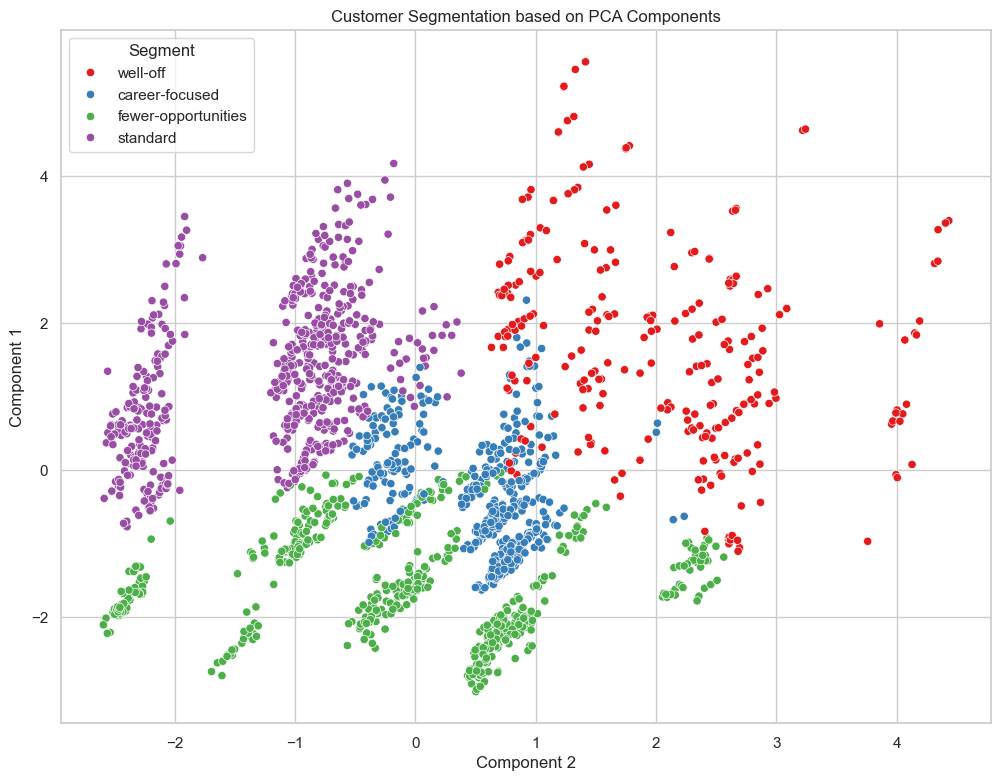

In [50]:
x_axis = df_segm_pca_kmeans['Component 2']
y_axis = df_segm_pca_kmeans['Component 1']
plt.figure(figsize=(12, 9))
sns.scatterplot(x=x_axis, y=y_axis, hue=df_segm_pca_kmeans['Legend'], palette='Set1')
plt.title('Customer Segmentation based on PCA Components')
plt.xlabel('Component 2')
plt.ylabel('Component 1')
plt.legend(title='Segment')
plt.show()

In [52]:
### save data using joblib
joblib.dump(df_segm_pca_kmeans, 'models/customer_segments_pca_kmeans.pkl')

['models/customer_segments_pca_kmeans.pkl']

In [53]:
joblib.dump(pca, 'models/pca_model.pkl')
joblib.dump(kmeans_pca, 'models/kmeans_pca_model.pkl')
joblib.dump(scaler, 'models/scaler_model.pkl')

['models/scaler_model.pkl']